# CNN 예제
본 노트북은 노션 페이지 내용을 바탕으로하고 있습니다. 상세한 내용은 노션 페이지를 참조해주세요.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data = datasets.OxfordIIITPet(root='./data', split='trainval', target_types='category', transform=transform, download=True)
test_dataset = datasets.OxfordIIITPet(root='./data', split='test', target_types='category', transform=transform, download=True)

val_size = int(0.6 * len(test_dataset))
test_size = len(test_dataset) - val_size

val_data, test_data = random_split(test_dataset, [val_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [ ]:
print("train data의 수 :", len(train_data))
print("validation data의 수 :", len(val_data))
print("test data의 수 :", len(test_data))

train data의 수 : 3680
validation data의 수 : 2201
test data의 수 : 1468


In [ ]:
print(len(train_data.classes))

37


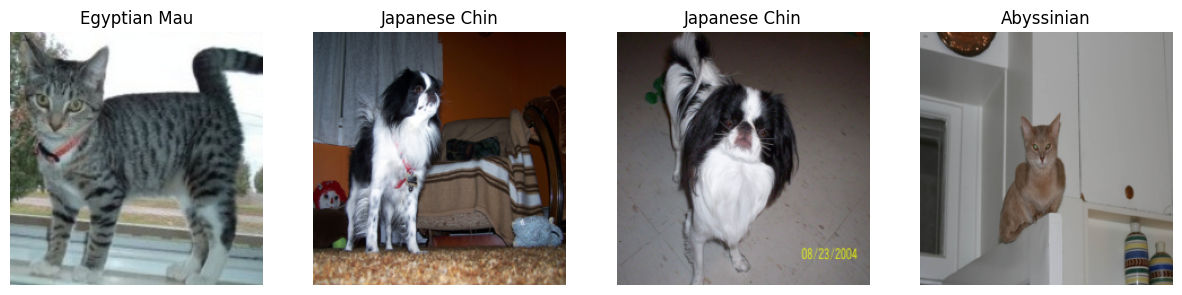

In [ ]:
def imshow(img, ax, title=None):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img.numpy().transpose((1, 2, 0))  # (C, H, W) -> (H, W, C)로 변경
    img = std * img + mean  # 정규화 해제 (normalize의 반대 작업)
    img = np.clip(img, 0, 1)  # 값의 범위를 0에서 1로 클리핑하여 시각화할 수 있게 맞춤

    ax.imshow(img)
    if title is not None:
        ax.set_title(title)
    ax.axis('off')

dataiter = iter(train_loader)
images, labels = next(dataiter)

fig, axs = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    imshow(images[i], axs[i], title=train_data.classes[labels[i]])

plt.show()


In [ ]:
labels[:4]

tensor([11, 17, 17,  0])

In [ ]:
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

model.classifier[6] = nn.Linear(4096, 37)

model = model.to(device)

for param in model.features.parameters():
    param.requires_grad = False

In [ ]:
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=1):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.cuda(), labels.cuda()

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Train Accuracy: {train_accuracy:.2f}%", end = " ")

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.cuda(), labels.cuda()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_accuracy = 100 * val_correct / val_total
        print(f"Validation Loss: {val_loss/len(val_loader):.4f}, Validation Accuracy: {val_accuracy:.2f}%")
        model.train()

train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=1)


Epoch [1/1], Loss: 1.8166, Train Accuracy: 56.22% Validation Loss: 0.7703, Validation Accuracy: 76.74%


In [ ]:
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")

# 모델 평가
evaluate_model(model, test_loader)


Test Accuracy: 76.84%


In [ ]:
def visualize_feature_maps(model, input_image, num_layer):
    model.eval()
    outputs = []
    names = []

    def hook_fn(module, input, output):
        outputs.append(output)
        names.append(module.__class__.__name__)

    hooks = []
    for layer in model.features:
        if isinstance(layer, torch.nn.Conv2d):
            hooks.append(layer.register_forward_hook(hook_fn))

    input_image = input_image.unsqueeze(0).to(device)
    model(input_image)

    for hook in hooks:
        hook.remove()

    feature_map = outputs[num_layer].squeeze(0).detach().cpu().numpy()
    num_channels = feature_map.shape[0]

    print(f"layer ", num_layer)
    plt.figure(figsize=(15, 15))
    for j in range(min(8, num_channels)):
        plt.subplot(1, 8, j+1)
        plt.imshow(feature_map[j], cmap='viridis')
        plt.axis('off')

    plt.show()

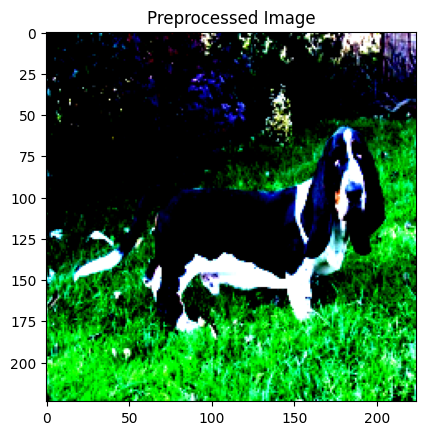

layer  0


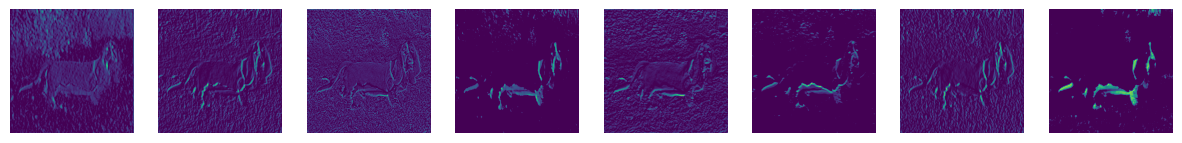

layer  1


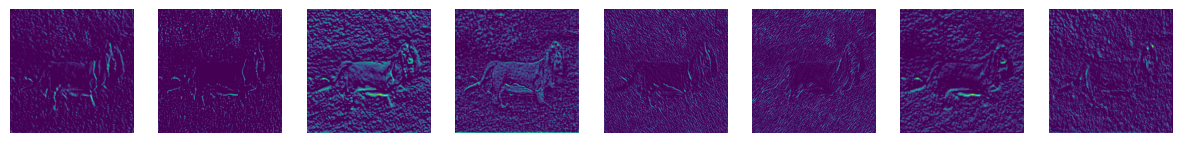

layer  2


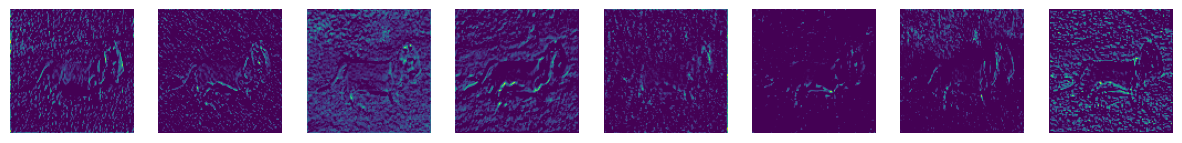

layer  3


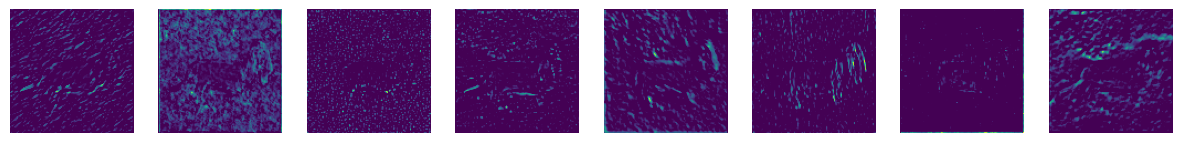

layer  4


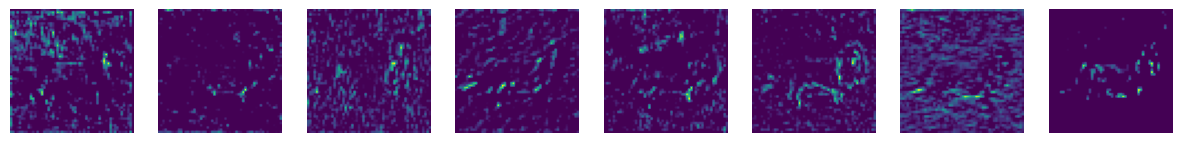

layer  5


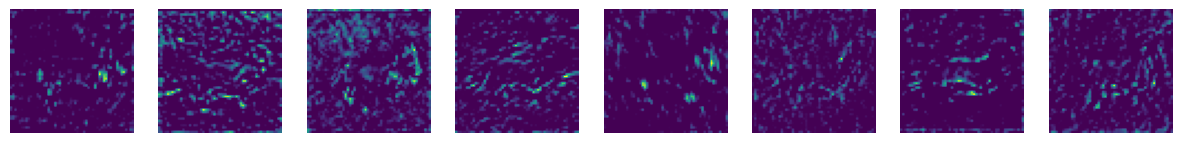

layer  6


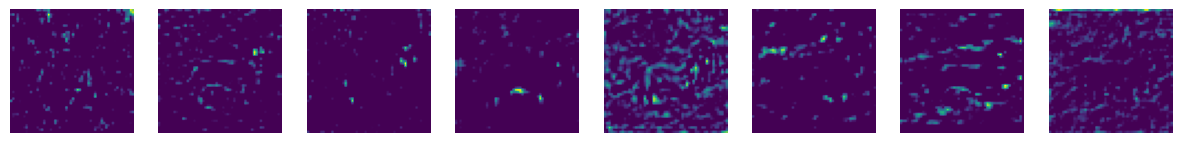

layer  7


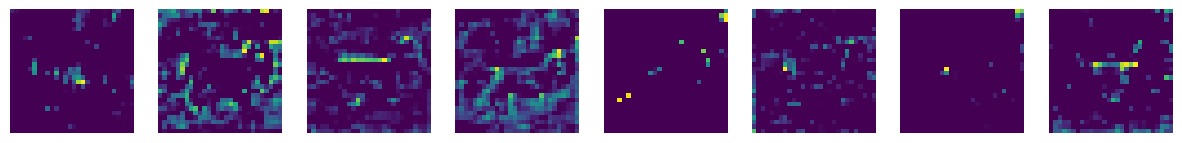

layer  8


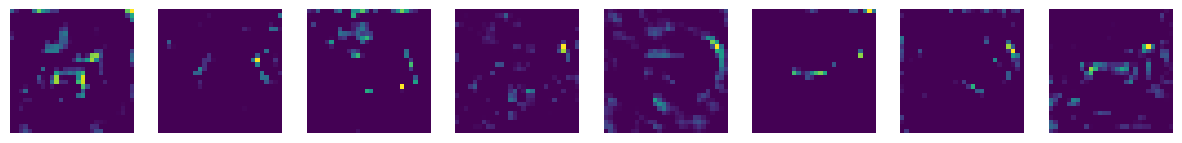

layer  9


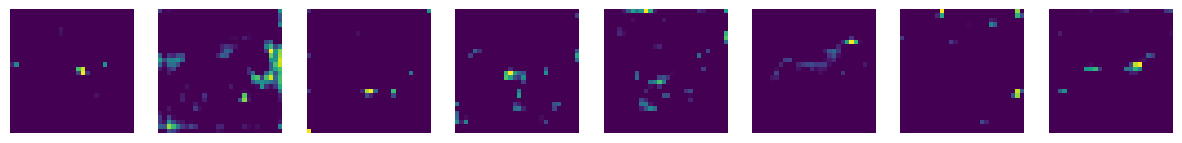

layer  10


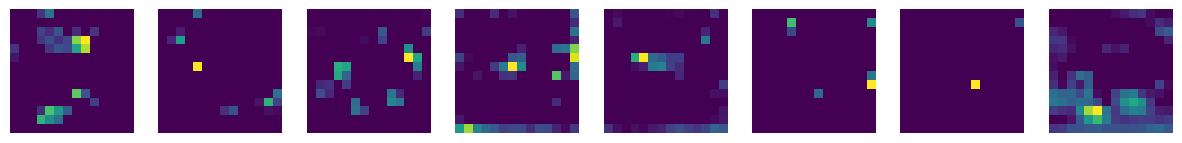

layer  11


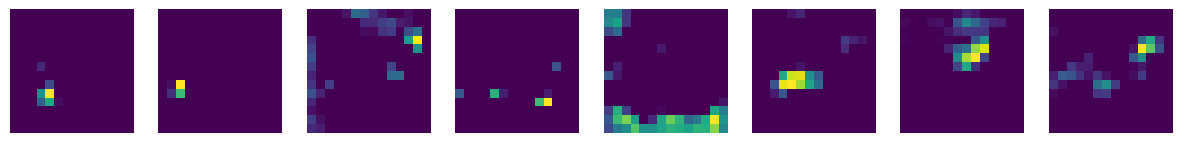

layer  12


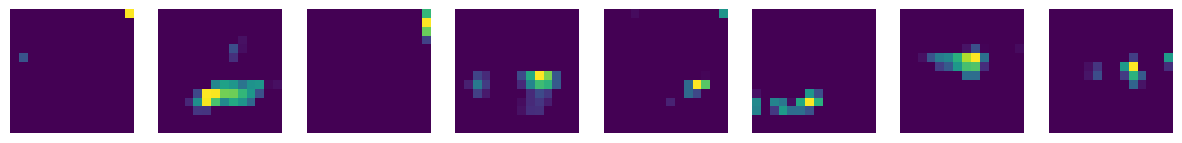

In [ ]:
sample_img, _ = test_data[0]

plt.title("Preprocessed Image")
plt.imshow(sample_img.permute(1, 2, 0))
plt.show()

for i in range(13):
    visualize_feature_maps(model, sample_img, num_layer=i)

In [ ]:
def inference_result(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
    return outputs[0], predicted[0], labels[0]

output, predicted, label = inference_result(model, test_loader)
print("모델의 인퍼런스 값\n", output)
print("모델이 예측한 class :", predicted)
print("실제 class :", label)

모델의 인퍼런스 값
 tensor([-25.1333, -17.3968, -23.3440, -16.9470, -13.8851, -16.6745, -20.2134,
        -30.2301, -14.6796, -23.4734, -30.9462, -17.2292,  -8.6150,  -9.7885,
        -21.6442,  -5.8969, -15.3766, -19.6319, -15.2404,   8.9813, -12.1693,
        -33.2374, -17.7881, -19.8359, -23.4148, -13.5557, -19.3268, -30.2930,
          1.3216, -20.0114, -25.9285, -21.6917, -23.9147, -32.1319, -21.7893,
         -7.9293, -28.0777], device='cuda:0')
모델이 예측한 class : tensor(19, device='cuda:0')
실제 class : tensor(19, device='cuda:0')
